In [ ]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import sys
sys.path.append("../../")
import InfoGlobe
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import hsv_to_rgb, rgb_to_hsv
from InfoGlobe.plot import factor_sort, factor_plot
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
adata = sc.read_h5ad('pancreas_acinar_res.h5ad')

In [ ]:
X = adata.obsm['infoglobe_embedding']
n_factors = X.shape[1]

tech = adata.obs['tech'].values

f_values_tech, _ = f_classif(X, tech)
tech_df = pd.DataFrame({
    'Factor': range(n_factors),
    'tech_F_Score': f_values_tech
})

tech_df = tech_df.sort_values('tech_F_Score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=tech_df.head(30), 
    x=tech_df.head(30)['Factor'].astype(str), 
    y='tech_F_Score', 
    palette='Reds_r'
)
plt.title("Top 30 tech-Associated Factors (Sorted by F-Score)")
plt.xticks(rotation=45)
plt.show()

print("--- sorted Top 30 Factor ---")
print(list(tech_df['Factor'].head(30)))

In [4]:
adata_tech = adata[
    adata.obs.sort_values('tech').index
]

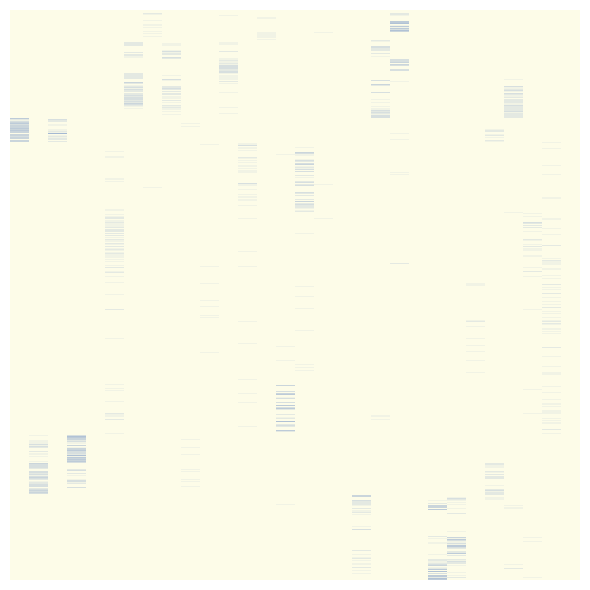

In [ ]:
from matplotlib.colors import ListedColormap
moon_colors = [
    "#FDFCE8",
    "#F1F3E5",
    "#E4E9E2",
    "#D7DFDF",
    "#CAD5DB",
    "#BDCBD8",
    "#B1C2D5",
    "#A4B8D2",
    "#97AECF",
    "#8AA4CB",
]

cmap = ListedColormap(moon_colors)
# cmap = ListedColormap(warm_colors)
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(
    # adata.obsm['infoglobe_embedding'],
    adata_tech.obsm['infoglobe_embedding'][:,[2, 39, 55, 43, 30, 28, 48, 22, 74, 50, 62, 18, 9, 21, 75, 68, 49, 34, 29, 53, 23, 16, 78, 42, 41, 36, 37, 1, 45, 72]],
    ax=ax,
    cmap=cmap,
    # vmax=0.5,
    # square=True,
    xticklabels=False,
    yticklabels=False,
    cbar=False,         
)

ax.set_axis_off()        
plt.tight_layout()
plt.show()

In [ ]:
def factor_sort(adata):
    embedding = adata.obsm['infoglobe_embedding']
    factor_matrix = adata.obsm['infoglobe_embedding'].T
    factor_linkage = linkage(
        pdist(factor_matrix, metric='correlation'),  
        method='ward'  
    )

    factor_order = leaves_list(factor_linkage)

    embedding_clustered = factor_matrix[factor_order, :]
    adata.obsm['infoglobe_embedding_clustered'] = embedding_clustered.T

    factor_labels = [f'factor_{i}' for i in range(embedding.shape[1])]
    factor_df = pd.DataFrame({
        'factor_id': factor_labels,
        'cluster_order': factor_order
    }).sort_values('cluster_order')
    return adata, factor_order

def factor_plot(adata, factor_order, label):
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        adata.obsm['infoglobe_embedding_clustered'],  
        cmap='coolwarm',
        vmax=0.5,
        center=0,
        xticklabels=[f'F{idx}' for idx in factor_order],  
        yticklabels=False,  
    )

    cell_types = adata.obs[label].values
    sort_idx = np.lexsort((np.arange(len(cell_types)), pd.Categorical(cell_types).codes))
    sorted_cell_types = cell_types[sort_idx]
    
    le = LabelEncoder()
    le.fit(cell_types)  
    sorted_cell_types_encoded = le.transform(sorted_cell_types)

    type_boundaries = np.where(np.diff(sorted_cell_types_encoded))[0] + 0.5

    for boundary in type_boundaries:
        plt.axhline(boundary, color='black', linewidth=1.0)

    unique_types = le.classes_
    type_positions = []
    for ct in unique_types:
        positions = np.where(sorted_cell_types == ct)[0]
        if len(positions) > 0:
            type_positions.append(positions.mean())

    plt.yticks(type_positions, unique_types, rotation=0)

    plt.xlabel('Factors (clustered order)')
    plt.ylabel('Cells (sorted by cell type)')
    plt.title('Infoglobe Embedding Heatmap with Cell Type Boundaries')
    plt.tight_layout()
    plt.show()
    return sorted_cell_types


In [ ]:
adata.obs['tech_'] = adata.obs['tech'].copy()

adata.obs['tech_'] = adata.obs['tech_'].cat.add_categories(['inDrop'])

mask = adata.obs['tech'].astype(str).str.contains('inDrop', na=False)
adata.obs.loc[mask, 'tech_'] = 'inDrop'

In [ ]:
_, tech_sorted = factor_sort(adata_tech)

In [ ]:
adata, factor_order = factor_sort(adata)
sorted_tech = factor_plot(
    adata,
    factor_order,
    label='tech'
)


In [ ]:
def tech_sorted_heatmap(adata, data_key, tech_order, order, figsize=(12, 8)):

    data = adata.obsm[data_key][:, order]
    moon_colors_red = [
        "#FDFCE8",  
        "#F1F3E5",  
        "#E4E9E2",  
        "#D7DFDF",  
        "#F0D0D0", 
        "#E8B8B8", 
        "#E0A0A0", 
        "#D88888", 
        "#D07070",  
        "#C85858", 
    ]

    cmap = LinearSegmentedColormap.from_list(
        'moon_red', 
        moon_colors_red, 
        N=256
    )

    sort_order = pd.Categorical(adata.obs['tech'], categories=tech_order, ordered=True)
    sort_idx = np.lexsort((np.arange(len(sort_order)), sort_order.codes))
    
    data_sorted = data[sort_idx, :]
    tech_sorted = adata.obs['tech'].iloc[sort_idx].values

    plt.figure(figsize=figsize)
    sns.heatmap(
        data_sorted,
        cmap=cmap,
        # center=0,
        vmax=0.15,
        xticklabels=False,  
        yticklabels=False,
        cbar_kws={'label': 'Expression'}
    )
    
    le = LabelEncoder()
    tech_encoded = le.fit_transform(tech_sorted)
    tech_boundaries = np.where(np.diff(tech_encoded))[0] + 0.5
    
    for boundary in tech_boundaries:
        plt.axhline(boundary, color='black', linewidth=0.2)
    
    unique_tech = le.classes_
    tech_positions = []
    for tech in unique_tech:
        positions = np.where(tech_sorted == tech)[0]
        if len(positions) > 0:
            tech_positions.append(positions.mean())
    
    plt.yticks(tech_positions, unique_tech, rotation=0)
    plt.xlabel('Factors')
    plt.ylabel('Cells (sorted by tech)')
    plt.title(f'{data_key} - Sorted by Technology')
    plt.tight_layout()
    plt.show()

tech_sorted_heatmap(adata, 'Infoglobe_embedding', np.unique(sorted_tech), [2, 39, 55, 43, 30, 28, 48, 22, 74, 50, 62, 18, 9, 21, 75, 68, 49, 34, 29, 53, 23, 16, 78, 42, 41, 36, 37, 1, 45, 72])